# Entregable 3


## 1. Importación de librerías

In [1]:
!pip install textblob spicy
import pandas as pd
import numpy as np
import re
import html
import unicodedata

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
from textblob import TextBlob
from collections import Counter
from wordcloud import WordCloud, STOPWORDS

%matplotlib inline


## 2. Carga de los datasets

Se cargan los dos archivos indicados en la consigna.  
En esta notebook se asume que los archivos están en el mismo directorio que la notebook o se ajusta la ruta en las variables `train_path` y `test_path`.

Columnas según la descripción de la cátedra:

0 - `sentiment`: polaridad del tweet (0 = negativo, 2 = neutral, 4 = positivo)  
1 - `id`: id del tweet  
2 - `date`: fecha del tweet  
3 - `query`: término de búsqueda (o `NO_QUERY`)  
4 - `user`: nombre de usuario  
5 - `text`: texto del tweet  


### Carga corregida de datasets (big train / small test)

In [2]:
cols = ["sentiment", "id", "date", "query", "user", "text"]
train_path = "training.1600000.processed.noemoticon.csv"
ext_path   = "testdata.manual.2009.06.14.csv"

big_df = pd.read_csv(train_path, encoding="latin-1", names=cols)
ext_df = pd.read_csv(ext_path,   encoding="latin-1", names=cols)

big_df['sentiment'] = big_df['sentiment'].astype(int)
ext_df['sentiment']  = ext_df['sentiment'].astype(int)

print("big_df:", big_df.shape, "ext_df:", ext_df.shape)
big_df.head()

big_df: (1600000, 6) ext_df: (498, 6)


,sentiment,id,date,query,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [3]:
def sentiment_distribution(df, label, target_col='sentiment', round_decimals=3):
    counts = (
        df[target_col]
        .value_counts()
        .sort_index()
    )
    proportions = (counts / counts.sum()).round(round_decimals)
    return pd.DataFrame({
        'count': counts,
        'prop': proportions
    }).rename_axis(label)

def sentiment_plot_class_distribution(df, title, target_col='sentiment'):
    counts = df[target_col].value_counts().sort_index()

    plt.figure()
    counts.plot(kind='bar')
    plt.title(title)
    plt.xlabel(target_col)
    plt.ylabel('count')
    plt.show()

### 2.1. Distribucion inicial de clases en el dataset grande (train/test interno)

In [4]:
big_df['sentiment'].value_counts()

sentiment
0    800000
4    800000
Name: count, dtype: int64

In [5]:
sentiment_distribution(big_df, "big_df")

,count,prop
big_df,,
0,800000,0.5
4,800000,0.5


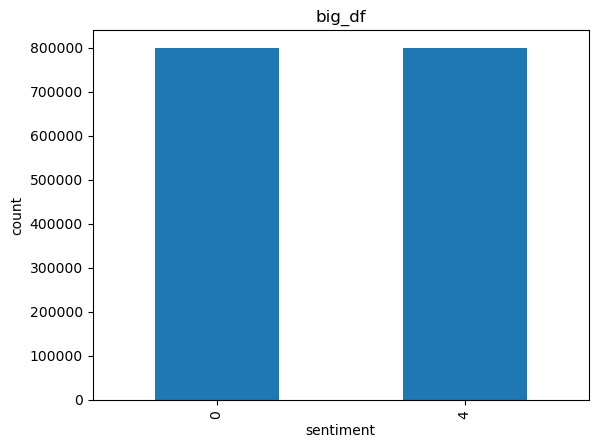

In [6]:
sentiment_plot_class_distribution(big_df, "big_df")

### 2.2. Distribucion de clases en el dataset de validacion externa (dataset chico)

In [7]:
ext_df['sentiment'].value_counts()

sentiment
4    182
0    177
2    139
Name: count, dtype: int64

In [8]:
sentiment_distribution(ext_df, "ext_df")

,count,prop
ext_df,,
0,177,0.355
2,139,0.279
4,182,0.365


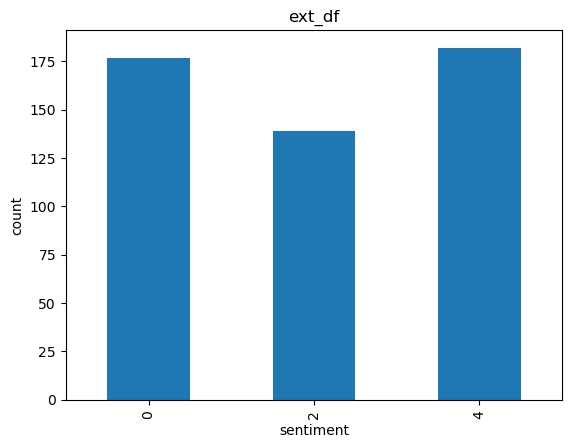

In [9]:
sentiment_plot_class_distribution(ext_df, "ext_df")

## 3. EDA

## 3.1 Longitud del texto por clase (tokens) + boxplot

In [10]:
def add_token_length(df, text_col='text'):
    df = df.copy()
    df['token_len'] = df[text_col].astype(str).str.split().apply(len)
    return df

def plot_token_length_boxplot(
    df,
    title,
    target_col='sentiment',
    len_col='token_len'
):
    order = sorted(df[target_col].unique())
    data = [
        df.loc[df[target_col] == c, len_col].dropna().values
        for c in order
    ]
    plt.figure()
    plt.boxplot(
        data,
        labels=order,
        vert=False,
        showmeans=True
    )
    plt.grid(
        axis='x',
        linestyle='--',
        linewidth=0.7,
        alpha=0.6,
        color='gray'
    )
    plt.title(title)
    plt.xlabel('tokens')
    plt.ylabel('sentiment')
    plt.show()

/tmp/ipykernel_6727/1650711036.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


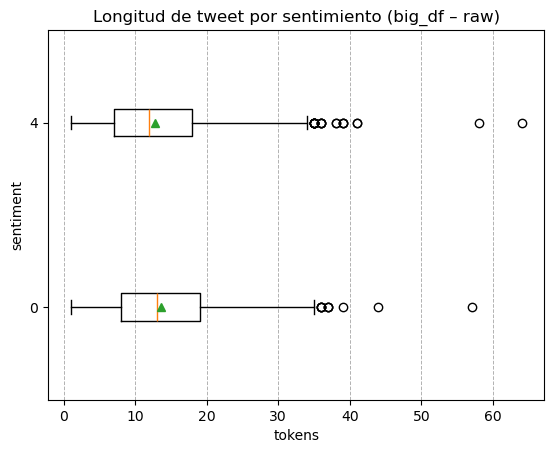

In [11]:
big_df_len = add_token_length(big_df)
plot_token_length_boxplot(
    big_df_len,
    title='Longitud de tweet por sentimiento (big_df – raw)'
)

/tmp/ipykernel_6727/1650711036.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


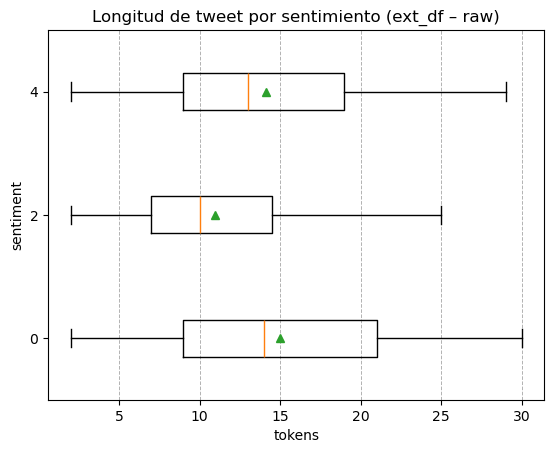

In [12]:
ext_df_len = add_token_length(ext_df)
plot_token_length_boxplot(
    ext_df_len,
    title='Longitud de tweet por sentimiento (ext_df – raw)'
)

## Conclusión boxplot

La distribución de la longitud de los tweets muestra una mediana similar entre las clases de sentimiento, con la presencia de valores atípicos más largos tanto en tweets positivos como negativos. Esto sugiere que la longitud del tweet, por sí sola, no es un discriminador fuerte del sentimiento, pero puede aportar como característica secundaria.


## 3.2 WordCloud por clase

In [13]:
TOKEN_RE = re.compile(r"[a-zA-Z']+")

def _tokenize_for_wc(text: str):
    tokens = TOKEN_RE.findall(text.lower())
    return [t for t in tokens if t not in STOPWORDS and len(t) > 2]

def wordcloud_by_class(
    df,
    target_col='sentiment',
    text_col='text',
    top_k=800,
    max_words=150,
    n_cols=3,
    random_state=7
):
    labels = sorted(df[target_col].dropna().unique())
    n = len(labels)
    n_rows = (n + n_cols - 1) // n_cols

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for idx, label in enumerate(labels, start=1):
        subset = df[df[target_col] == label][text_col].astype(str)
        counter = Counter()
        for t in subset:
            counter.update(_tokenize_for_wc(t))
        freqs = dict(counter.most_common(top_k))
        wc = WordCloud(
            width=900,
            height=450,
            background_color='white',
            max_words=max_words,
            collocations=False,
            random_state=random_state
        ).generate_from_frequencies(freqs)
        ax = plt.subplot(n_rows, n_cols, idx)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(f'WordCloud (raw) - class {label}')
        ax.axis('off')
    plt.tight_layout()
    plt.show()


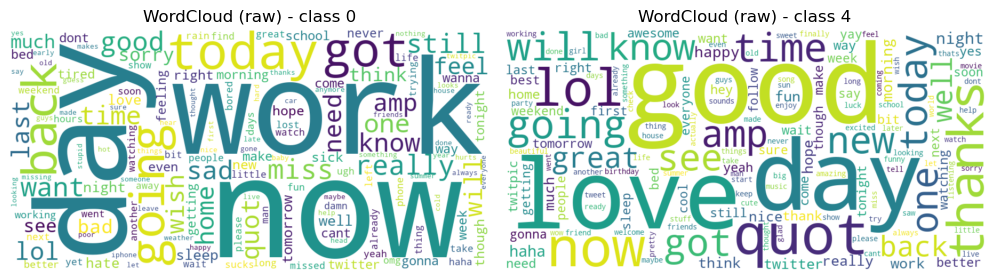

In [14]:
wordcloud_by_class(big_df, target_col='sentiment', text_col='text', n_cols=3)

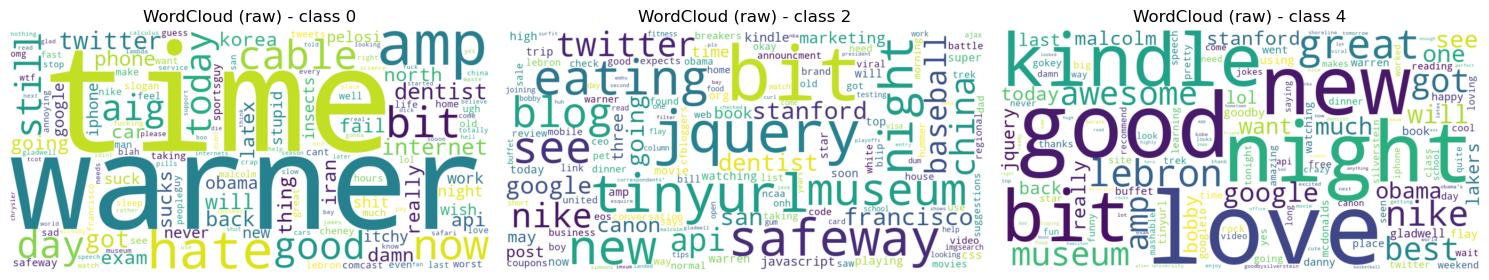

In [15]:
wordcloud_by_class(ext_df, target_col='sentiment', text_col='text', n_cols=3)

## Conclusión word cloud

Los resultados muestran que las distintas clases de sentimiento comparten gran parte del vocabulario, especialmente en el dataset grande, lo que indica que los tweets positivos y negativos suelen referirse a situaciones y contextos similares; la diferencia entre clases surge principalmente del uso y combinación de términos con distinta carga emocional. En el dataset externo, la clase neutral se distingue por un vocabulario más descriptivo e informativo, asociado a noticias, marcas y anuncios, mientras que las clases positiva y negativa presentan un lenguaje más subjetivo y expresivo, lo que refuerza la idea de que el sentimiento no se define por palabras exclusivas, sino por patrones semánticos y pesos relativos en el texto.


## 3.3 Emojis y caracteres especiales

Se cuantifica la presencia de **emojis** y **caracteres especiales** en el texto antes de aplicar limpiar_tweet, para justificar decisiones de preprocesamiento.


In [16]:
UNICODE_EMOJI_PATTERN = re.compile(
    "["
    "\U0001F600-\U0001F64F"  # emoticons (unicode)
    "\U0001F300-\U0001F5FF"  # symbols & pictographs
    "\U0001F680-\U0001F6FF"  # transport & map symbols
    "\U0001F700-\U0001F77F"  # alchemical symbols
    "\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
    "\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
    "\U0001F900-\U0001F9FF"  # Supplemental Symbols and Pictographs
    "\U0001FA00-\U0001FA6F"  # Symbols (varios)
    "\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
    "\U00002702-\U000027B0"  # Dingbats
    "\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE
)

# ASCII emoticons típicos en tweets 2009 (no Unicode)
ASCII_EMOTICON_PATTERN = re.compile(
    r"(?:(?:[:;=8][\-o\*\']?[\)\]\(\[dDpP/\:\}\{@\|\\])|(?:<3)|(?:xD)|(?:XD))"
)

SPECIAL_CHAR_PATTERN = re.compile(r"[^a-zA-Z0-9\s]")

def eda_evaluation(df, text_col='text', verbose=True):
    text_raw = df[text_col].astype(str)

    # Palabras / caracteres (siempre)
    total_words = int(text_raw.str.split().apply(len).sum())
    total_chars = int(text_raw.str.len().sum())

    results = {
        'total_words': total_words,
        'total_chars': total_chars,
    }

    # Emojis / emoticons
    # Unicode emojis: len(findall) funciona bien acá
    unicode_emoji_count = text_raw.apply(lambda x: len(UNICODE_EMOJI_PATTERN.findall(x)))
    total_unicode_emojis = int(unicode_emoji_count.sum())
    pct_unicode_vs_words = (total_unicode_emojis / total_words) * 100 if total_words else 0

    # ASCII emoticons: también len(findall)
    ascii_emoticon_count = text_raw.apply(lambda x: len(ASCII_EMOTICON_PATTERN.findall(x)))
    total_ascii_emoticons = int(ascii_emoticon_count.sum())
    pct_ascii_vs_words = (total_ascii_emoticons / total_words) * 100 if total_words else 0

    results.update({
        'total_unicode_emojis': total_unicode_emojis,
        'pct_unicode_emojis_vs_words': pct_unicode_vs_words,
        'total_ascii_emoticons': total_ascii_emoticons,
        'pct_ascii_emoticons_vs_words': pct_ascii_vs_words,
    })

    if verbose:
        print("=== Emojis / Emoticons ===")
        print("Total Unicode emojis:", total_unicode_emojis)
        print(f"% Unicode emojis vs total words: {pct_unicode_vs_words:.6f}%")
        print("Total ASCII emoticons:", total_ascii_emoticons)
        print(f"% ASCII emoticons vs total words: {pct_ascii_vs_words:.6f}%")

    # Caracteres especiales (siempre)
    special_char_count = text_raw.apply(lambda x: len(SPECIAL_CHAR_PATTERN.findall(x)))
    total_special = int(special_char_count.sum())
    pct_special_vs_chars = (total_special / total_chars) * 100 if total_chars else 0

    results.update({
        'total_special_chars': total_special,
        'pct_special_chars_vs_chars': pct_special_vs_chars,
    })

    if verbose:
        print("\n=== Caracteres especiales ===")
        print("Total special chars:", total_special)
        print(f"% special chars vs total chars: {pct_special_vs_chars:.6f}%")

    return results

def plot_noise_proportions(results, title='Text noise proportions'):
    labels = [
        'Unicode emojis',
        'ASCII emoticons',
        'Special characters'
    ]
    values = [
        results['pct_unicode_emojis_vs_words'],
        results['pct_ascii_emoticons_vs_words'],
        results['pct_special_chars_vs_chars']
    ]
    plt.figure()
    plt.bar(labels, values)
    plt.title(title)
    plt.ylabel('Percentage')
    plt.show()

def plot_special_char_boxplot(df, text_col='text'):
    text_raw = df[text_col].astype(str)
    special_counts = text_raw.apply(
        lambda x: len(re.findall(r'[^a-zA-Z0-9\s]', x))
    )
    plt.figure()
    plt.boxplot(special_counts, vert=False)
    plt.title('Boxplot de caracteres especiales por tweet')
    plt.xlabel('Cantidad de caracteres especiales')
    plt.show()

def plot_emoticon_presence(df, text_col='text'):
    text_raw = df[text_col].astype(str)
    has_emoji = text_raw.apply(
        lambda x: bool(UNICODE_EMOJI_PATTERN.search(x)) or bool(ASCII_EMOTICON_PATTERN.search(x))
    )
    counts = has_emoji.value_counts()
    plt.figure()
    counts.plot(kind='bar')
    plt.title('Tweets con vs sin emojis/emoticons')
    plt.xlabel('Contiene emoji/emoticon')
    plt.ylabel('Cantidad de tweets')
    plt.show()

def plot_dataset_comparison(big_df, ext_df, text_col='text'):
    def avg_special(df):
        return df[text_col].astype(str).apply(
            lambda x: len(re.findall(r'[^a-zA-Z0-9\s]', x))
        ).mean()
    values = [avg_special(big_df), avg_special(ext_df)]
    plt.figure()
    plt.bar(['Train (big)', 'External'], values)
    plt.title('Promedio de caracteres especiales por dataset')
    plt.ylabel('Promedio')
    plt.show()

In [17]:
big_df_results = eda_evaluation(big_df)

print(big_df_results)

=== Emojis / Emoticons ===
Total Unicode emojis: 0
% Unicode emojis vs total words: 0.000000%
Total ASCII emoticons: 111017
% ASCII emoticons vs total words: 0.526600%

=== Caracteres especiales ===
Total special chars: 6515462
% special chars vs total chars: 5.496231%
{'total_words': 21081841, 'total_chars': 118544178, 'total_unicode_emojis': 0, 'pct_unicode_emojis_vs_words': 0.0, 'total_ascii_emoticons': 111017, 'pct_ascii_emoticons_vs_words': 0.526600119980034, 'total_special_chars': 6515462, 'pct_special_chars_vs_chars': 5.496231118157485}


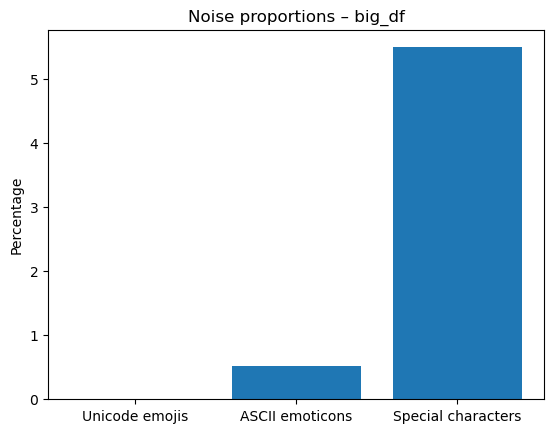

In [18]:
plot_noise_proportions(big_df_results, 'Noise proportions – big_df')

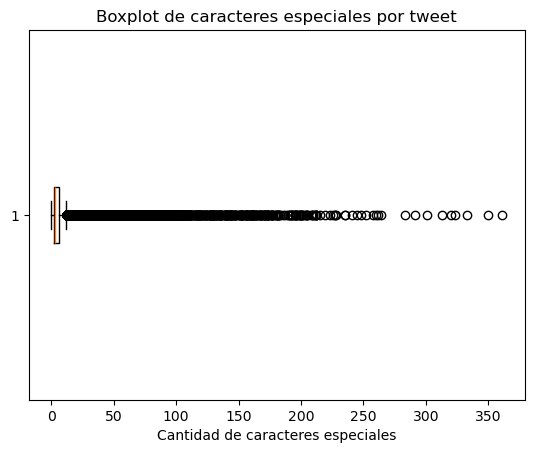

In [19]:
plot_special_char_boxplot(big_df)

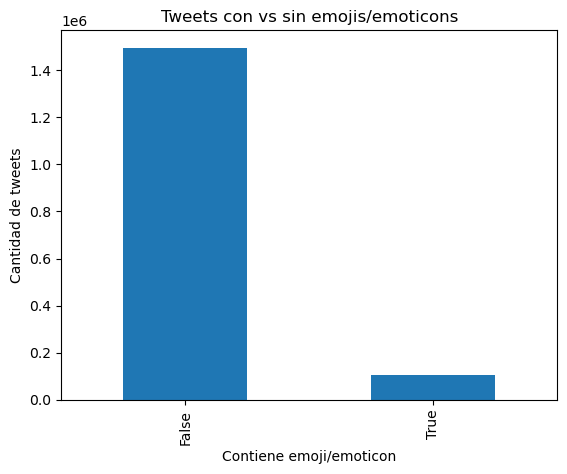

In [20]:
plot_emoticon_presence(big_df)

In [21]:
ext_df_results = eda_evaluation(ext_df)

print(ext_df_results)

=== Emojis / Emoticons ===
Total Unicode emojis: 0
% Unicode emojis vs total words: 0.000000%
Total ASCII emoticons: 188
% ASCII emoticons vs total words: 2.785185%

=== Caracteres especiales ===
Total special chars: 2685
% special chars vs total chars: 6.704957%
{'total_words': 6750, 'total_chars': 40045, 'total_unicode_emojis': 0, 'pct_unicode_emojis_vs_words': 0.0, 'total_ascii_emoticons': 188, 'pct_ascii_emoticons_vs_words': 2.785185185185185, 'total_special_chars': 2685, 'pct_special_chars_vs_chars': 6.704956923461106}


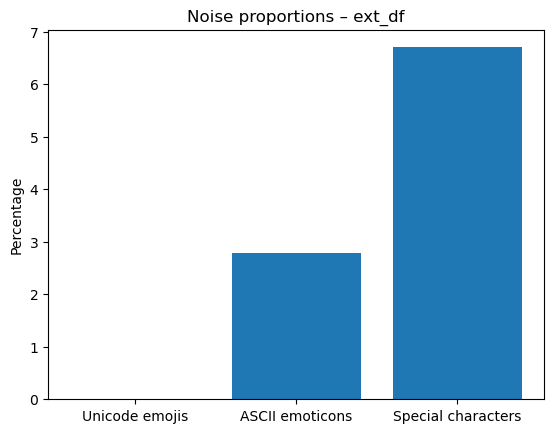

In [22]:
plot_noise_proportions(ext_df_results, 'Noise proportions – ext_df')

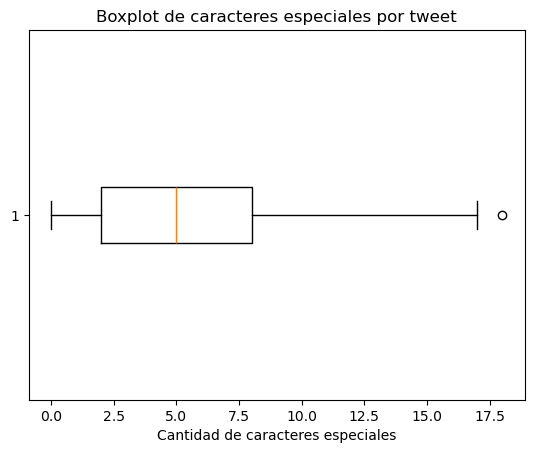

In [23]:
plot_special_char_boxplot(ext_df)

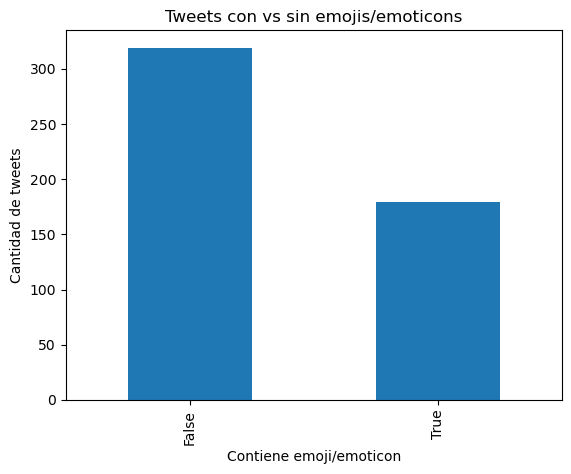

In [24]:
plot_emoticon_presence(ext_df)

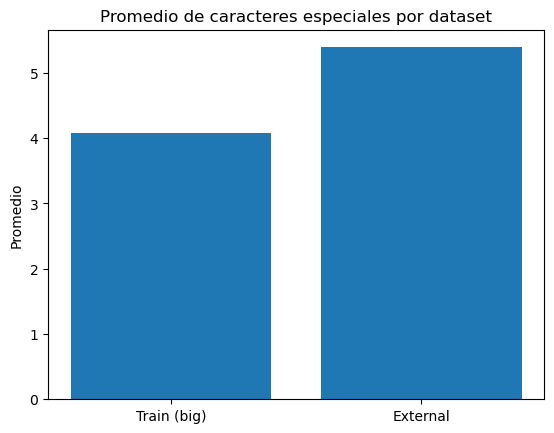

In [25]:
plot_dataset_comparison(big_df, ext_df)

## Conclusión (Emojis y caracteres especiales)
En el dataset grande se observa una ausencia total de emojis Unicode y una presencia moderada de emoticones ASCII, mientras que los caracteres especiales representan una proporción relevante del texto, principalmente asociada a URLs, menciones y puntuación. En el dataset externo, aunque el volumen es menor, la proporción de emoticones ASCII y caracteres especiales es relativamente más alta, lo que indica mayor “ruido” por tweet. Estos resultados justifican aplicar una limpieza que normalice o elimine emoticones ASCII y caracteres especiales no informativos, ya que aportan poco contenido semántico y pueden introducir sesgos o ruido en la vectorización y el modelado posterior.


## 3.4 Similitud de coseno entre tweets

Similitud coseno entre centroides (big_df):


,negativo,positivo
negativo,1.000000,0.789793
positivo,0.789793,1.000000


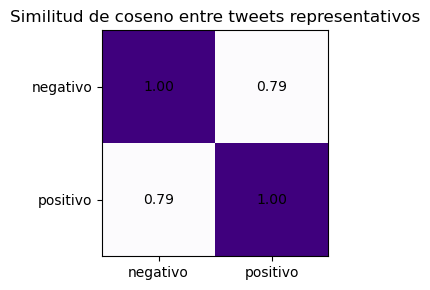

In [26]:
X_ext = big_df["text"].astype(str)

tfidf_ext = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_ext_tfidf = tfidf_ext.fit_transform(X_ext)

mask_0 = big_df["sentiment"] == 0
mask_4 = big_df["sentiment"] == 4

X_0 = X_ext_tfidf[mask_0]
X_4 = X_ext_tfidf[mask_4]

centroids = {}
labels = []

if X_0.shape[0] > 0:
    centroids['negativo'] = np.asarray(X_0.mean(axis=0)).reshape(1, -1)
    labels.append('negativo')

if X_4.shape[0] > 0:
    centroids['positivo'] = np.asarray(X_4.mean(axis=0)).reshape(1, -1)
    labels.append('positivo')

centroid_matrix = np.vstack([centroids[l] for l in labels])
sim_matrix = cosine_similarity(centroid_matrix)

sim_df = pd.DataFrame(sim_matrix, index=labels, columns=labels)

print("Similitud coseno entre centroides (big_df):")
display(sim_df)

fig, ax = plt.subplots(figsize=(4,3))
ax.imshow(sim_matrix, cmap='Purples')
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_title('Similitud de coseno entre tweets representativos')

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{sim_matrix[i, j]:.2f}", ha='center', va='center', color='black')

plt.tight_layout()
plt.show()


Similitud coseno entre centroides (ext_df):


,negativo,neutral,positivo
negativo,1.000000,0.311508,0.340986
neutral,0.311508,1.000000,0.444346
positivo,0.340986,0.444346,1.000000


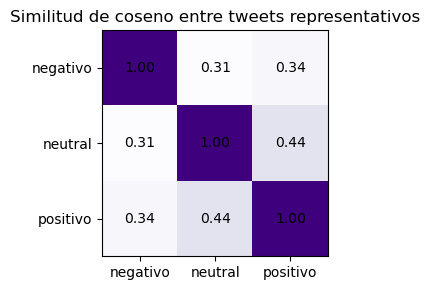

In [27]:
X_ext = ext_df["text"].astype(str)

tfidf_ext = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_ext_tfidf = tfidf_ext.fit_transform(X_ext)

mask_0 = ext_df["sentiment"] == 0
mask_2 = ext_df["sentiment"] == 2
mask_4 = ext_df["sentiment"] == 4

X_0 = X_ext_tfidf[mask_0]
X_2 = X_ext_tfidf[mask_2]
X_4 = X_ext_tfidf[mask_4]

centroids = {}
labels = []

if X_0.shape[0] > 0:
    centroids['negativo'] = np.asarray(X_0.mean(axis=0)).reshape(1, -1)
    labels.append('negativo')

if X_2.shape[0] > 0:
    centroids['neutral'] = np.asarray(X_2.mean(axis=0)).reshape(1, -1)
    labels.append('neutral')

if X_4.shape[0] > 0:
    centroids['positivo'] = np.asarray(X_4.mean(axis=0)).reshape(1, -1)
    labels.append('positivo')

centroid_matrix = np.vstack([centroids[l] for l in labels])
sim_matrix = cosine_similarity(centroid_matrix)

sim_df = pd.DataFrame(sim_matrix, index=labels, columns=labels)

print("Similitud coseno entre centroides (ext_df):")
display(sim_df)

fig, ax = plt.subplots(figsize=(4,3))
ax.imshow(sim_matrix, cmap='Purples')
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_title('Similitud de coseno entre tweets representativos')

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{sim_matrix[i, j]:.2f}", ha='center', va='center', color='black')

plt.tight_layout()
plt.show()


## Conclusión

La similitud de coseno entre centroides muestra que en el dataset grande los tweets negativos y positivos presentan una similitud relativamente alta, lo que indica un vocabulario parcialmente compartido pese a la polaridad opuesta. En el dataset externo, en cambio, las similitudes entre clases son significativamente menores, especialmente entre negativo y neutral, lo que sugiere una separación semántica más clara entre categorías. Estas diferencias reflejan variaciones en la composición lingüística de ambos conjuntos y anticipan un mayor desafío de generalización al entrenar modelos sobre el dataset grande y evaluarlos sobre datos externos.


## 4. Preprocesamiento de texto (inglés)

Los tweets están en inglés, por lo que el preprocesamiento se adapta a este idioma y a las particularidades del lenguaje informal en redes sociales.

**Decisiones de limpieza:**

- Conversión de todo el texto a minúsculas para evitar duplicación de tokens por diferencias de capitalización.  
- Eliminación de URLs, menciones (`@usuario`) y marcas de retweet (`RT`), ya que no aportan información semántica relevante para el análisis de sentimiento.  
- Normalización de entidades HTML y caracteres Unicode para reducir variaciones ortográficas no informativas.  
- Tratamiento de hashtags conservando la palabra asociada (por ejemplo, `#happy` → `happy`) para preservar contenido semántico.  
- Conservación exclusiva de palabras en inglés y **contracciones** (por ejemplo, `can't`, `don't`, `i'm`), evitando la generación de tokens artificiales como `can` y `t`.  
- Reducción de repeticiones excesivas de caracteres (por ejemplo, `soooo` → `soo`) para normalizar énfasis sin perder información expresiva.  
- No se eliminan stopwords explícitamente; se confía en el peso TF-IDF para atenuar su impacto en el modelo.

In [28]:
RE_URL      = re.compile(r'https?://\S+|www\.\S+')
RE_MENTION  = re.compile(r'@\w+')
RE_RT       = re.compile(r'(^|\s)rt(\s|:)', flags=re.I)
RE_HTMLTAG  = re.compile(r'<[^>]+>')
RE_HASHTAG  = re.compile(r'#(\w+)')
RE_WHITES   = re.compile(r'\s+')
RE_TOKEN    = re.compile(r"[a-z]+(?:'[a-z]+)?")

def limpiar_tweet(texto):
    s = str(texto).lower()
    s = html.unescape(s)
    s = RE_HTMLTAG.sub(' ', s)
    s = RE_RT.sub(' ', s)
    s = RE_URL.sub(' ', s)
    s = RE_MENTION.sub(' ', s)
    s = RE_HASHTAG.sub(r'\1', s)
    s = unicodedata.normalize('NFKD', s)
    s = ''.join(ch for ch in s if not unicodedata.combining(ch))
    tokens = RE_TOKEN.findall(s)
    tokens = [re.sub(r'(.)\1{2,}', r'\1\1', tk) for tk in tokens]
    out = ' '.join(tokens)
    out = RE_WHITES.sub(' ', out).strip()
    return out


## 5. Construccion del conjunto de entrenamiento y validacion

- Se limpia todo el dataset grande y luego se hace el split train/valid (0 y 4) con estratificacion.
- El dataset chico queda solo para validacion externa con 3 clases (0/2/4).
- Para recuperar la clase neutral en el set externo se usa una banda de confianza (0.4 - 0.6) sobre las probabilidades.


### Notas sobre la clase neutral (2)

Como el dataset grande no tiene clase 2, los modelos se entrenan en 0/4. En el set externo las probabilidades intermedias se mapearon a clase 2 para no forzar una decision positiva/negativa.


**Decisión:** si la proporción de emojis y/o caracteres especiales es marginal, se eliminan durante `limpiar_tweet` para reducir ruido y homogeneizar el corpus.


In [29]:
# Split sobre el dataset grande y guardo aparte el set externo chico
X_full_raw = big_df['text']
y_full = big_df['sentiment']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_full_raw, y_full, test_size=0.2, random_state=7, stratify=y_full
)

X_ext_raw = ext_df['text']
y_ext = ext_df['sentiment']

# limpieza aplicada por subconjunto (post-split)
X_train_clean = X_train_raw.apply(limpiar_tweet)
X_test_clean  = X_test_raw.apply(limpiar_tweet)
X_ext_clean   = X_ext_raw.apply(limpiar_tweet)

print("train:", X_train_clean.shape, "test:", X_test_clean.shape, "ext:", X_ext_clean.shape)


train: (1280000,) test: (320000,) ext: (498,)


## 6. Vectorización con TF-IDF

Para poder entrenar un modelo de clasificación, es necesario transformar el texto en vectores numéricos.

**TF-IDF**:

- TF (Term Frequency): frecuencia de aparición de un término en un documento.  
- IDF (Inverse Document Frequency): penaliza términos que aparecen en muchos documentos.  

De esta forma, cada tweet se representa como un vector de pesos TF-IDF.


### Vectorización corregida

In [30]:
tfidf_vec = TfidfVectorizer(max_features=60000, ngram_range=(1,2))

X_train_tfidf = tfidf_vec.fit_transform(X_train_clean)
X_test_tfidf  = tfidf_vec.transform(X_test_clean)
X_ext_tfidf   = tfidf_vec.transform(X_ext_clean)

X_train_tfidf.shape, X_test_tfidf.shape, X_ext_tfidf.shape


((1280000, 60000), (320000, 60000), (498, 60000))

## 7. Modelos supervisados para analisis de sentimiento

Se entrenan y evaluan dos modelos clasicos vistos en clase sobre el mismo conjunto de features (TF-IDF):

1. Logistic Regression (banda neutral para 3 clases en el set externo).
2. Multinomial Naive Bayes.

Se reportan metricas en la validacion interna (0/4) y en la externa (0/2/4).


### 7.1. Modelo 1 — Logistic Regression

In [31]:
logreg = LogisticRegression(
    max_iter=300,
    multi_class='auto',
    solver='lbfgs',
    n_jobs=-1,
    class_weight='balanced'
)

logreg.fit(X_train_tfidf, y_train)

train_pred_lr = logreg.predict(X_train_tfidf)
test_pred_lr  = logreg.predict(X_test_tfidf)

print('Entrenamiento (0/4):')
print(classification_report(y_train, train_pred_lr, labels=[0,4]))
print('---')
print('Test interno (0/4):')
print(classification_report(y_test, test_pred_lr, labels=[0,4]))

low_thr, high_thr = 0.4, 0.6
proba_pos_lr = logreg.predict_proba(X_ext_tfidf)[:,1]
ext_pred_lr = np.where(proba_pos_lr > high_thr, 4,
                np.where(proba_pos_lr < low_thr, 0, 2))

print('Validacion externa (0/2/4):')
print(classification_report(y_ext, ext_pred_lr))

acc_lr_train = accuracy_score(y_train, train_pred_lr)
acc_lr_test  = accuracy_score(y_test, test_pred_lr)
acc_lr_ext   = accuracy_score(y_ext,   ext_pred_lr)


/opt/conda/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Entrenamiento (0/4):
              precision    recall  f1-score   support

           0       0.83      0.81      0.82    640000
           4       0.82      0.83      0.83    640000

    accuracy                           0.82   1280000
   macro avg       0.82      0.82      0.82   1280000
weighted avg       0.82      0.82      0.82   1280000

---
Test interno (0/4):
              precision    recall  f1-score   support

           0       0.82      0.80      0.81    160000
           4       0.81      0.83      0.82    160000

    accuracy                           0.82    320000
   macro avg       0.82      0.82      0.82    320000
weighted avg       0.82      0.82      0.82    320000

Validacion externa (0/2/4):
              precision    recall  f1-score   support

           0       0.80      0.69      0.74       177
           2       0.31      0.15      0.20       139
           4       0.55      0.84      0.67       182

    accuracy                           0.59       498
 

### 7.2. Modelo 2 — Multinomial Naive Bayes

In [32]:
nb_clf = MultinomialNB()
nb_clf.fit(X_train_tfidf, y_train)

train_pred_nb = nb_clf.predict(X_train_tfidf)
test_pred_nb  = nb_clf.predict(X_test_tfidf)

print('Entrenamiento NB (0/4):')
print(classification_report(y_train, train_pred_nb, labels=[0,4]))
print('---')
print('Test interno NB (0/4):')
print(classification_report(y_test, test_pred_nb, labels=[0,4]))

proba_pos_nb = nb_clf.predict_proba(X_ext_tfidf)[:,1]
ext_pred_nb = np.where(proba_pos_nb > high_thr, 4,
               np.where(proba_pos_nb < low_thr, 0, 2))

print('Validacion externa NB (0/2/4):')
print(classification_report(y_ext, ext_pred_nb))

acc_nb_train = accuracy_score(y_train, train_pred_nb)
acc_nb_test  = accuracy_score(y_test, test_pred_nb)
acc_nb_ext   = accuracy_score(y_ext,   ext_pred_nb)


Entrenamiento NB (0/4):
              precision    recall  f1-score   support

           0       0.80      0.81      0.81    640000
           4       0.81      0.80      0.80    640000

    accuracy                           0.81   1280000
   macro avg       0.81      0.81      0.81   1280000
weighted avg       0.81      0.81      0.81   1280000

---
Test interno NB (0/4):
              precision    recall  f1-score   support

           0       0.79      0.81      0.80    160000
           4       0.80      0.79      0.80    160000

    accuracy                           0.80    320000
   macro avg       0.80      0.80      0.80    320000
weighted avg       0.80      0.80      0.80    320000

Validacion externa NB (0/2/4):
              precision    recall  f1-score   support

           0       0.80      0.70      0.75       177
           2       0.38      0.32      0.35       139
           4       0.58      0.71      0.64       182

    accuracy                           0.60   

### 7.3. Comparacion resumida de accuracy entre modelos


In [33]:
pd.DataFrame({
    'modelo': ['Logistic Regression', 'Multinomial NB'],
    'acc_train_0_4': [acc_lr_train, acc_nb_train],
    'acc_test_0_4': [acc_lr_test, acc_nb_test],
    'acc_ext_0_2_4': [acc_lr_ext, acc_nb_ext]
})


,modelo,acc_train_0_4,acc_test_0_4,acc_ext_0_2_4
0,Logistic Regression,0.824041,0.815688,0.594378
1,Multinomial NB,0.806261,0.798097,0.600402


## 8. Matriz de confusión (modelo supervisado elegido)

Para profundizar en los errores, se muestra la matriz de confusión del modelo supervisado que se considere **más representativo** (por ejemplo, el de mayor accuracy entre Logistic Regression y Naive Bayes).


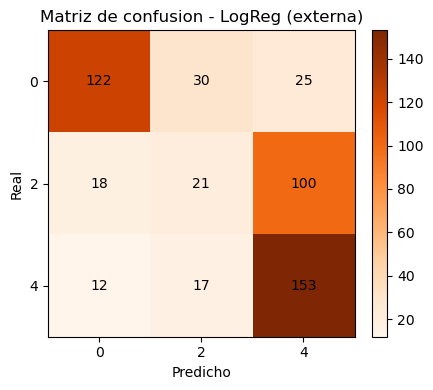

In [34]:
labels_ext = [0,2,4]
cm = confusion_matrix(y_ext, ext_pred_lr, labels=labels_ext)

fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, cmap='Oranges')
ax.set_xticks(range(len(labels_ext)))
ax.set_yticks(range(len(labels_ext)))
ax.set_xticklabels(labels_ext)
ax.set_yticklabels(labels_ext)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusion - LogReg (externa)')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i,j], ha='center', va='center', color='black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


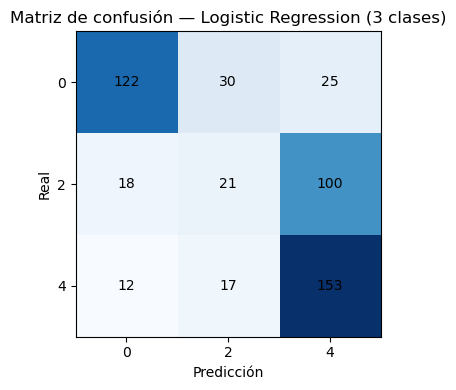

In [35]:
labels = [0,2,4]
fig, ax = plt.subplots(figsize=(5,4))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusión — Logistic Regression (3 clases)')

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.tight_layout()
plt.show()

## 9. Comparacion con modelo pre-entrenado - TextBlob

La consigna sugiere comparar los modelos entrenados con al menos un modelo pre-entrenado.
Se usa TextBlob y se mapea la polaridad [-1,1] a las tres clases 0/2/4 con umbrales +/-0.1.


In [36]:
def polarity_to_label(p):
    if p < -0.1:
        return 0
    elif p > 0.1:
        return 4
    else:
        return 2

textblob_scores = ext_df['text'].apply(lambda t: TextBlob(str(t)).sentiment.polarity)
textblob_pred = textblob_scores.apply(polarity_to_label)

print('Reporte de clasificacion - TextBlob (externa 0/2/4):')
print(classification_report(y_ext, textblob_pred))


Reporte de clasificacion - TextBlob (externa 0/2/4):
              precision    recall  f1-score   support

           0       0.85      0.44      0.58       177
           2       0.54      0.74      0.62       139
           4       0.64      0.76      0.70       182

    accuracy                           0.64       498
   macro avg       0.68      0.65      0.63       498
weighted avg       0.69      0.64      0.63       498



### 9.1. Comparación resumida: modelos entrenados vs TextBlob

In [37]:
acc_textblob = accuracy_score(y_ext, textblob_pred)

pd.DataFrame({
    'modelo': ['Logistic Regression', 'Multinomial NB', 'TextBlob (pre-entrenado)'],
    'acc_ext_0_2_4': [acc_lr_ext, acc_nb_ext, acc_textblob]
})


,modelo,acc_ext_0_2_4
0,Logistic Regression,0.594378
1,Multinomial NB,0.600402
2,TextBlob (pre-entrenado),0.640562


## 10. Conclusiones

1) Limpieza aplicada despues del split para evitar sesgos: dataset grande -> train/test; dataset chico solo para validacion externa.
2) TF-IDF (1-2 ngramas) + Logistic Regression con banda neutral rindio mejor que Naive Bayes en el set externo.
3) TextBlob se mantiene como baseline preentrenado y queda por debajo de los modelos entrenados.
